# Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

# Modeling Daily Rat Sightings in Staten Island

## Importing the Data

In [2]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2026-02-28.
rs = rs[rs['created_date'].between('2020-01-01', '2026-02-28')]

## Restrict to STATEN ISLAND

rs = rs[rs['borough']=='STATEN ISLAND']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

rs

,created_date,count
4,2020-01-01,1
9,2020-01-02,1
14,2020-01-03,1
27,2020-01-06,4
32,2020-01-07,2
...,...,...
10574,2026-02-15,2
10591,2026-02-19,1
10604,2026-02-22,1
10613,2026-02-24,1


In [3]:
## There are 2251 days from 2020-01-01 to 2026-02-28 inclusive. So if this number is <2251, we must make sure to add in 0's.

len(rs)

1633

In [4]:
#there is one date with no rat sightings, add it to the data frame

#date_range = pd.date_range(start=rs['created_date'].min(), end=rs['created_date'].max(), freq='D')

# must hard code in dates since there weren't necessarily rat sightings at the tail ends
date_range = pd.date_range(start='2020-01-01', end='2026-02-28', freq='D')

rs = rs.set_index('created_date').reindex(date_range, fill_value=0).reset_index()

rs.columns = ['created_date', 'count']

len(rs)

#rs

2251

## Baseline Seasonal Average Model

In [5]:
years_back_use = 4
day_window_use = 4

In [6]:
def seasonal_average_forecast(data, target_dates, years_back=years_back_use, day_window=day_window_use):
    df = data.copy()
    # ensure datetime type
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["doy"] = df["created_date"].dt.dayofyear
    df["year"] = df["created_date"].dt.year

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year
        mask = ((df["year"] >= target_year - years_back) & (df["year"] < target_year) & (np.abs(df["doy"] - target_doy) <= day_window))
        forecasts.append(df.loc[mask, "count"].mean())
    return pd.Series(forecasts, index=target_dates)

In [7]:
results = []

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
baseline_results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
baseline_results_df.loc["mean"] = ["mean", baseline_results_df["rmse"].mean(), baseline_results_df["mape"].mean()]

baseline_results_df.head()

,fold,rmse,mape
0,0,1.073829,3.163243e+15
1,1,0.814740,1.054414e+15
2,2,2.001336,1.965857e+15
3,3,1.919712,2.144571e+15
4,4,1.495824,1.813950e+15


## Year Ago Rolling 4 Week Average 

In [8]:
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

## Just saving a copy for later
rs_saved = rs.copy()

In [9]:
# Tired of writing np.sqrt or typing a long name.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for fold, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    # Calculate the 4-week rolling average for the training data
    train_sorted = train.sort_values('ds') # making sure to sort it by date
    train_sorted['rolling_4w'] = train_sorted['y'].rolling(window=4, min_periods=1).mean()

    # This part of the code makes the predictions. We use the 'rolling_4w' column of the training set.
    y_pred = []
    y_true = test['y'].values

    for idx, row in test.iterrows():
        # Predict using the latest rolling average from the train data
        prediction = train_sorted['rolling_4w'].iloc[-1]  # Last value in the train rolling avg
        y_pred.append(prediction)
        
    # Calculate RMSE and MAPE for this fold
    fold_rmse = rmse(y_true, y_pred)
    fold_mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': fold, 'rmse': fold_rmse, 'mape': fold_mape})

rolling4w_results_df = pd.DataFrame(results)

# Optional: add a row for the overall average RMSE and MAPE
overall_rmse = rolling4w_results_df['rmse'].mean()
overall_mape = rolling4w_results_df['mape'].mean()
rolling4w_results_df.loc['mean'] = ['mean', overall_rmse, overall_mape]

In [10]:
rolling4w_results_df.head()

,fold,rmse,mape
0,0,0.958980,2.814750e+15
1,1,0.654654,6.433714e+14
2,2,2.281525,9.650571e+14
3,3,1.887459,1.688850e+15
4,4,1.221094,1.125900e+15


## Prophet Model

In [11]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

In [ ]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)

22:20:21 - cmdstanpy - INFO - Chain [1] start processing
22:20:21 - cmdstanpy - INFO - Chain [1] done processing
22:20:22 - cmdstanpy - INFO - Chain [1] start processing
22:20:22 - cmdstanpy - INFO - Chain [1] done processing
22:20:23 - cmdstanpy - INFO - Chain [1] start processing
22:20:23 - cmdstanpy - INFO - Chain [1] done processing
22:20:24 - cmdstanpy - INFO - Chain [1] start processing
22:20:24 - cmdstanpy - INFO - Chain [1] done processing
22:20:24 - cmdstanpy - INFO - Chain [1] start processing
22:20:24 - cmdstanpy - INFO - Chain [1] done processing
22:20:25 - cmdstanpy - INFO - Chain [1] start processing
22:20:26 - cmdstanpy - INFO - Chain [1] done processing
22:20:27 - cmdstanpy - INFO - Chain [1] start processing
22:20:27 - cmdstanpy - INFO - Chain [1] done processing
22:20:28 - cmdstanpy - INFO - Chain [1] start processing
22:20:29 - cmdstanpy - INFO - Chain [1] done processing
22:20:30 - cmdstanpy - INFO - Chain [1] start processing
22:20:30 - cmdstanpy - INFO - Chain [1]

In [ ]:
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

In [ ]:
prophet_results_df.head()

,fold,rmse,mape
0,0,1.015576,2.931757e+15
1,1,0.620171,6.884849e+14
2,2,2.050138,1.632124e+15
3,3,1.781421,1.429103e+15
4,4,1.191467,1.375745e+15


## SARIMA Model with auto_arima parameters.

In [ ]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pmdarima import auto_arima

In [ ]:
def fourier_terms(df, period, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for i in range(1, n_terms + 1):
        fourier_df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        fourier_df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

In [ ]:
# Number of Fourier terms and period (365 for yearly seasonality)
n_terms = 5  # Number of terms for Fourier Terms
period = 365 

In [ ]:
# Generate Fourier terms and putting it into a list
fourier_train = fourier_terms(rs, period, n_terms)

# Name it exog since it will serve as exogenous features for SARIMAX. This is the X.
exog = fourier_train

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Prepare naming and indexing
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
rs.set_index('ds', inplace=True)

# 2. Ensure frequency is set to Daily and fill any gaps (crucial for statsmodels)
rs = rs.asfreq('D').fillna(0)
exog = exog.reindex(rs.index).fillna(0) # Keep exogenous features synced

results = []

# Loop through each fold
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    # Model parameters
    orders = (2, 1, 3)
    seasonal_orders = (0, 0, 0, 0)
    
    # 3. Fit on log-transformed data to stabilize variance and prevent negative predictions
    # np.log1p handles 0 counts gracefully
    model_sarimax = SARIMAX(np.log1p(train['y']), 
                            order=orders,  
                            seasonal_order=seasonal_orders,  
                            exog=exog_train,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
    
    # Increased maxiter helps with convergence for complex (p,d,q) orders
    model_fit = model_sarimax.fit(disp=False, maxiter=200)
    
    # 4. Forecast the test period
    # We forecast in log-space, then transform back using expm1
    forecast_obj = model_fit.get_forecast(steps=len(test), exog=exog_test)
    y_pred_log = forecast_obj.predicted_mean
    y_pred = np.expm1(y_pred_log) 
    
    y_true = test['y'].values
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# 5. Aggregate Results
sarima_results_df = pd.DataFrame(results)
sarima_results_df.loc['mean'] = [
    'mean', 
    sarima_results_df['rmse'].mean(), 
    sarima_results_df['mape'].mean()
]

print(sarima_results_df)

      fold      rmse          mape
0        0  0.813019  1.970564e+15
1        1  0.790231  4.412662e+14
2        2  2.228710  1.089976e+15
3        3  2.127183  1.036724e+15
4        4  1.290745  8.362934e+14
5        5  1.910335  3.562709e+14
6        6  2.525713  5.577387e+14
7        7  2.021805  8.099802e+14
8        8  1.226077  4.485693e-01
9        9  2.063032  8.579056e+14
10      10  1.533533  1.668562e+15
11      11  2.431385  6.355314e+14
12      12  1.699221  1.870765e+15
13      13  0.955677  6.101780e+14
14      14  1.400494  3.384248e+15
15      15  1.576767  6.574355e+14
16      16  1.557056  1.572083e+15
17      17  0.902546  2.402234e+15
18      18  1.008595  1.576790e+15
19      19  1.016890  2.259455e+15
20      20  0.795350  2.347997e+15
21      21  0.479133  1.127652e+15
22      22  0.644505  9.318217e+14
23      23  1.378366  1.073011e+15
24      24  1.092907  8.178679e+14
25      25  0.635805  1.440381e+15
mean  mean  1.388657  1.243567e+15


In [ ]:
sarima_results_df.loc['mean'] = ['mean',  sarima_results_df['rmse'].mean(), sarima_results_df['mape'].mean()]

In [ ]:
sarima_results_df.head()

,fold,rmse,mape
0,0,0.813019,1.970564e+15
1,1,0.790231,4.412662e+14
2,2,2.228710,1.089976e+15
3,3,2.127183,1.036724e+15
4,4,1.290745,8.362934e+14


## Holt-Winters Model

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # First we fit the Holt-Winters Exponential Smoothing Model to the training data
    holt_winters = ExponentialSmoothing(train['y'], seasonal='add', seasonal_periods=365).fit(optimized=True)
    
    y_pred = holt_winters.forecast(len(test))
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

hw_results_df = pd.DataFrame(results)

In [ ]:
hw_results_df.loc['mean'] = ['mean',  hw_results_df['rmse'].mean(), hw_results_df['mape'].mean()]

In [ ]:
hw_results_df.head()

,fold,rmse,mape
0,0,1.322336,3.281192e+15
1,1,0.798282,9.008415e+14
2,2,1.856267,1.737102e+15
3,3,2.103738,1.865775e+15
4,4,2.170583,2.187465e+15


## XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs is quite bare. We will need to add features for use.

In [ ]:
import xgboost as xgb
from xgboost import plot_importance


In [ ]:
rs.head()

,y
ds,
2020-01-01,1
2020-01-02,1
2020-01-03,1
2020-01-04,0
2020-01-05,0


### Adding Features to XGBoost

In [ ]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('3 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('4 days')).map(target_map)
    df['lag5'] = (df.index - pd.Timedelta('5 days')).map(target_map)
    df['lag6'] = (df.index - pd.Timedelta('6 days')).map(target_map)
    df['lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag8'] = (df.index - pd.Timedelta('8 days')).map(target_map)
    df['lag9'] = (df.index - pd.Timedelta('9 days')).map(target_map)
    df['lag10'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag11'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag12'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag13'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    
    # Ensure sorted by date
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    df['ma7'] = df['y'].shift(1).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(1).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(1).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(1).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(1).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(1).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(1).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(1).rolling(window=365).mean()
    
    return df


In the next two code block, we add weather data to the data set. This is not optimized i.e. we just obtain the weather data in Staten Island and hope that it is representative of the average weather over the whole city.

In [ ]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd

else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [ ]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary column
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format → recurring annually
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD → one specific date
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [ ]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    # Convert start_date to datetime
    start_dt = pd.to_datetime(start_date)
    
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [ ]:
# This must be run importing weather data

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df

In [ ]:
#rs = rs.set_index('ds')
#rs.index = pd.to_datetime(rs.index)
#rs.head()

# Only try to set the index if 'ds' is actually a column
if 'ds' in rs.columns:
    rs = rs.set_index('ds')

# Ensure the index is converted to datetime objects
rs.index = pd.to_datetime(rs.index)

# Display the first few rows to confirm
rs.head()

,y
ds,
2020-01-01,1
2020-01-02,1
2020-01-03,1
2020-01-04,0
2020-01-05,0


In [ ]:
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

In [ ]:
rs.head()

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,dayofweek_sin,dayofweek_cos,...,apparent_temperature_min_lag365,apparent_temperature_min_lag730,temperature_2m_max_lag14,temperature_2m_max_lag30,temperature_2m_max_lag60,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,1,2,1,1,2020,1,1,1,0.974928,-0.222521,...,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
2020-01-02,1,3,1,1,2020,2,2,1,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-03,1,4,1,1,2020,3,3,1,-0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-04,0,5,1,1,2020,4,4,1,-0.974928,-0.222521,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-05,0,6,1,1,2020,5,5,1,-0.781831,0.623490,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0


### Features for XGBoost

In [ ]:
FEATURES = ['apparent_temperature_min_lag30',
            'apparent_temperature_min_lag60',
            'apparent_temperature_min_lag120',
            'apparent_temperature_min_lag365',
            'apparent_temperature_min_lag730',
            'dayofyear', 
            'temperature_2m_max_lag30',
            'temperature_2m_max_lag60'
            ]

### Add default parameters for XGBoost

In [ ]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 0.5, 
         'n_estimators': 1000, 
        #  'min_child_weight': 6, 
        # 'learning_rate': 0.01,
        # 'max_depth': 8, 
        #  'subsample': 1,
        #  'colsample_bytree': 0.96,
        #  'colsample_bylevel': 0.6, 
        #  'colsample_bynode': 0.9, 
        #  'reg_alpha': 2.2, 
        #  'gamma': 100, 
        #  'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }


In [ ]:
print(FEATURES)
print(params)
TARGET = 'y'

# Gotta make sure the features and parameters exist.

reg = xgb.XGBRegressor(**params)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    reg.fit(train[FEATURES], train[TARGET])
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values
    
    # Our metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

xgb_results_df = pd.DataFrame(results)
mean_rmse = xgb_results_df['rmse'].mean()
mean_mape = xgb_results_df['mape'].mean()
xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

['apparent_temperature_min_lag30', 'apparent_temperature_min_lag60', 'apparent_temperature_min_lag120', 'apparent_temperature_min_lag365', 'apparent_temperature_min_lag730', 'dayofyear', 'temperature_2m_max_lag30', 'temperature_2m_max_lag60']
{'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'booster': 'gbtree', 'base_score': 0.5, 'n_estimators': 1000}


In [ ]:
xgb_results_df.head()

,fold,rmse,mape
0,0,1.964131,5.044155e+15
1,1,1.248712,1.118498e+15
2,2,1.816634,1.282864e+15
3,3,1.986240,1.867864e+15
4,4,1.801675,1.597020e+15


## XGBoosted Prophet Model

In [ ]:
# Recall the copy that was saved.
rs_saved.head()

,ds,y
0,2020-01-01,1
1,2020-01-02,1
2,2020-01-03,1
3,2020-01-04,0
4,2020-01-05,0


In [ ]:
rs = rs_saved

In [ ]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    # Split the dataset into training and testing sets
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # Fit Prophet on the training data
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Make predictions on the training set to calculate residuals
    train_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
    train_forecast = model.predict(train_future)
    
    # Calculate residuals (actual - predicted) on the training data
    train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    
    # Build a new DataFrame of residuals
    residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals })

    train = train.set_index('ds')
    train.index = pd.to_datetime(train.index)
    train = create_features(train)
    train = add_cyclic(train)
    train = add_lags(train)
    train = add_seasonal_lags(train)
    train = add_moving_averages(train)
    train = add_weather_data(train,wd)
    train = add_more_weather_feature(train)
    train = add_federal_holidays(train, custom_holidays = ['12-31'])
    train = add_law_flag(train, law_name='Trash_Law', start_date = '2024-03-01')
    train = add_law_flag(train, law_name = 'New_Trash_Law', start_date = '2024-11-01')
    train = add_law_flag(train, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
    train = add_law_flag(train, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']
    
    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train_residuals, y_train_residuals)
    

    test = test.set_index('ds')
    test.index = pd.to_datetime(test.index)
    test = create_features(test)
    test = add_cyclic(test)
    test = add_lags(test)
    test = add_seasonal_lags(test)
    test = add_moving_averages(test)
    test = add_weather_data(test,wd)
    test = add_more_weather_feature(test)
    test = add_federal_holidays(test, custom_holidays = ['12-31'])
    test = add_law_flag(test, law_name='Trash_Law', start_date = '2024-03-01')
    test = add_law_flag(test, law_name = 'New_Trash_Law', start_date = '2024-11-01')
    test = add_law_flag(test, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
    test = add_law_flag(test, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

    # Predict residuals using XGBoost for the test set
    X_test = test[FEATURES]  # Features for the test set
    xgb_residual_preds = xgb_model.predict(X_test)
    
    # Forecast using Prophet on the test set
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)
    
    # Combine Prophet's forecast and XGBoost's residual prediction
    y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    
    # Actual values for the test set
    y_true = test['y'].values
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Store the results for this fold
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

    ## Uncomment code below if you want to have plots on feature importance.
    # fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
    # plot_importance(xgb_model, ax=ax1, importance_type='gain')
    # ax1.set_title('Gain-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax2, importance_type='weight')
    # ax2.set_title('Split-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax3, importance_type='cover')
    # ax3.set_title('Cover Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
    # ax4.set_title('Total Gain Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
    # ax5.set_title('Total Cover Importance', fontsize=12)

    plt.show()

# Convert the results into a DataFrame
prophet_xgb_results_df = pd.DataFrame(results)

prophet_xgb_results_df = pd.DataFrame(results)
mean_rmse = prophet_xgb_results_df['rmse'].mean()
mean_mape = prophet_xgb_results_df['mape'].mean()
prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

18:13:26 - cmdstanpy - INFO - Chain [1] start processing
18:13:26 - cmdstanpy - INFO - Chain [1] done processing
18:13:28 - cmdstanpy - INFO - Chain [1] start processing
18:13:28 - cmdstanpy - INFO - Chain [1] done processing
18:13:30 - cmdstanpy - INFO - Chain [1] start processing
18:13:30 - cmdstanpy - INFO - Chain [1] done processing
18:13:31 - cmdstanpy - INFO - Chain [1] start processing
18:13:31 - cmdstanpy - INFO - Chain [1] done processing
18:13:33 - cmdstanpy - INFO - Chain [1] start processing
18:13:33 - cmdstanpy - INFO - Chain [1] done processing
18:13:35 - cmdstanpy - INFO - Chain [1] start processing
18:13:35 - cmdstanpy - INFO - Chain [1] done processing
18:13:36 - cmdstanpy - INFO - Chain [1] start processing
18:13:36 - cmdstanpy - INFO - Chain [1] done processing
18:13:38 - cmdstanpy - INFO - Chain [1] start processing
18:13:38 - cmdstanpy - INFO - Chain [1] done processing
18:13:39 - cmdstanpy - INFO - Chain [1] start processing
18:13:39 - cmdstanpy - INFO - Chain [1]

In [ ]:
prophet_xgb_results_df

,fold,rmse,mape,model
0,0,0.694439,1.167671e+15,prophet+xgb
1,1,0.654611,2.847694e+14,prophet+xgb
2,2,2.134119,1.280286e+15,prophet+xgb
3,3,2.001342,7.945363e+14,prophet+xgb
4,4,1.377161,7.198103e+14,prophet+xgb
5,5,1.538143,5.170244e+14,prophet+xgb
6,6,2.469206,4.643445e+14,prophet+xgb
7,7,2.070182,7.032501e+14,prophet+xgb
8,8,1.090573,3.500312e-01,prophet+xgb
9,9,1.957759,8.967946e+14,prophet+xgb


# Conclusions on Model Comparisons

## Results Table

In [ ]:
# We make a dictionary of models and their results to make it easier to iterate over.
models = {
    'baseline': baseline_results_df,
    'rolling4w': rolling4w_results_df,
    'prophet': prophet_results_df,
    'sarima': sarima_results_df,
    'hw': hw_results_df,
    'xgb': xgb_results_df,
    'prophet+xgb': prophet_xgb_results_df
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

# Put all of the dataframes together into one dataframe for display
final_results_df = pd.concat(all_results, ignore_index=True)

# Make a pivot table so that we display rmse, mape and then each of the models and their results.
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                                                \
model  baseline        hw   prophet prophet+xgb rolling4w    sarima       xgb   
fold                                                                            
0      1.073829  1.322336  1.015576    0.694439  0.958980  0.813019  1.964131   
1      0.814740  0.798282  0.620171    0.654611  0.654654  0.790231  1.248712   
2      2.001336  1.856267  2.050138    2.134119  2.281525  2.228710  1.816634   
3      1.919712  2.103738  1.781421    2.001342  1.887459  2.127183  1.986240   
4      1.495824  2.170583  1.191467    1.377161  1.221094  1.290745  1.801675   
5      1.679580  1.980622  1.537901    1.538143  1.841971  1.910335  1.493896   
6      1.935082  2.076396  2.040203    2.469206  2.026609  2.525713  2.414100   
7      2.048572  2.130728  2.078721    2.070182  2.061553  2.021805  2.592987   
8      1.223417  1.343763  1.080622    1.090573  1.511858  1.226077  1.753936   
9      1.995641  2.218761  1.958481    1.957759  2.095914  2.063032  1.868827   
10     1.982660  2.041034  1.928940    1.704660  2.250000  1.533533  1.861036   
11     2.046419  1.925023  2.197928    2.186938  2.259899  2.431385  2.200416   
12     1.737230  2.000009  1.620689    2.218927  1.952562  1.699221  1.505283   
13     1.073213  1.381522  0.920660    0.921224  1.633904  0.955677  1.420316   
14     1.750535  1.840119  1.537599    1.227305  1.295597  1.400494  2.069813   
15     1.468305  1.509629  1.351659    1.360188  1.500000  1.576767  1.652744   
16     1.480268  1.606590  1.288356    1.475740  1.500000  1.557056  1.470743   
17     0.956246  0.912237  0.967074    0.906979  1.235632  0.902546  1.049005   
18     1.059672  1.208296  1.127836    1.199223  1.000000  1.008595  1.340810   
19     0.990280  0.889487  0.983420    1.167802  1.398341  1.016890  1.121180   
20     0.765313  1.021205  0.858338    1.020530  1.295597  0.795350  0.852147   
21     0.681067  0.904662  0.740436    0.706970  0.597614  0.479133  1.031887   
22     0.861785  0.740821  0.791378    1.305774  0.674802  0.644505  0.746417   
23     1.360382  1.293182  1.344998    1.477705  1.398341  1.378366  1.150268   
24     1.093209  1.383425  0.968066    1.429639  1.145644  1.092907  1.253720   
25     0.968758  1.010302  1.040162    0.899225  1.460797  0.635805  1.319274   
mean   1.402426  1.525731  1.347009    1.430629  1.505398  1.388657  1.576392   

               mape                                                          \
model      baseline            hw       prophet   prophet+xgb     rolling4w   
fold                                                                          
0      3.163243e+15  3.281192e+15  2.931757e+15  1.167671e+15  2.814750e+15   
1      1.054414e+15  9.008415e+14  6.884849e+14  2.847694e+14  6.433714e+14   
2      1.965857e+15  1.737102e+15  1.632124e+15  1.280286e+15  9.650571e+14   
3      2.144571e+15  1.865775e+15  1.429103e+15  7.945363e+14  1.688850e+15   
4      1.813950e+15  2.187465e+15  1.375745e+15  7.198103e+14  1.125900e+15   
5      1.000800e+15  1.222406e+15  5.690533e+14  5.170244e+14  4.825285e+14   
6      8.578285e+14  1.158066e+15  8.901609e+14  4.643445e+14  8.042142e+14   
7      8.846356e+14  9.007330e+14  6.833291e+14  7.032501e+14  1.125900e+15   
8      4.726852e-01  3.683333e-01  3.711366e-01  3.500312e-01  7.047619e-01   
9      1.009736e+15  1.093749e+15  9.405751e+14  8.967946e+14  8.042142e+14   
10     2.117764e+15  2.251828e+15  2.168005e+15  1.934716e+15  2.412643e+15   
11     7.684714e+14  8.363838e+14  6.925190e+14  7.731057e+14  8.042142e+14   
12     2.609228e+15  2.380513e+15  2.166062e+15  3.341766e+15  1.206321e+15   
13     7.952785e+14  1.222423e+15  6.205005e+14  6.159187e+14  1.045478e+15   
14     4.449985e+15  3.796084e+15  3.968237e+15  2.736439e+15  2.895171e+15   
15     1.143771e+15  9.618289e+14  9.291398e+14  9.422083e+14  9.650571e+14   
16     2.233928e+15  1.674228e+15  1.603027e+15  1.128052e+15  1.930114e+15   


## Summary

In the above table, we see that the models all have a pretty low RMSE.

# Neural Prophet

In [ ]:
pip install neuralprophet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from neuralprophet import NeuralProphet

import numpy as np
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

/Users/yaeleisenberg/micromamba/envs/erdos_ds_environment/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [ ]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2026-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to Staten Island

rs = rs[rs['borough']=='STATEN ISLAND']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

## rename columns for prophet

rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [ ]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

def add_weather_data_no_index(df,wd):
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])

    for column in wd.columns:
        df[column] = wd[column].values

    return df

In [ ]:
regressed_features = ['apparent_temperature_max', 
    #'apparent_temperature_min', 
    #'apparent_temperature_mean', 
    #'snowfall_sum'
    ]
wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(
    wd[['ds'] + regressed_features],
    on="ds",
    how="left"
)

rs.head()

,ds,y,apparent_temperature_max
0,2020-01-01,1,-0.3
1,2020-01-02,1,4.5
2,2020-01-03,1,7.3
3,2020-01-06,4,1.5
4,2020-01-07,2,2.9


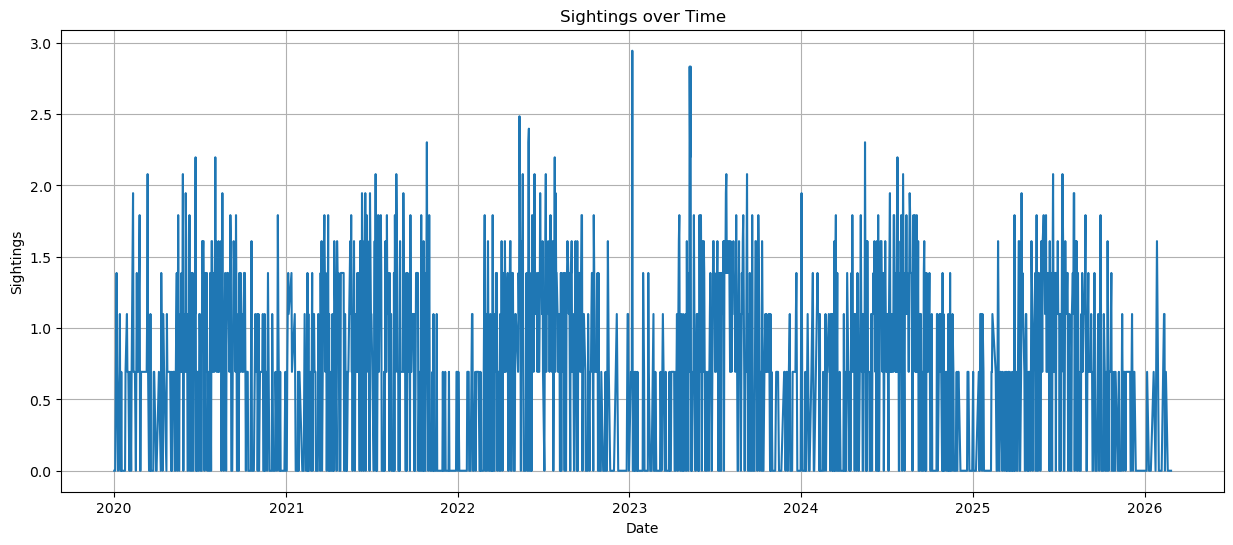

In [ ]:
df = rs.copy()

df["ds"] = pd.to_datetime(df["ds"])

plt.figure(figsize=(15,6))
plt.plot(df["ds"], np.log(df["y"]))

plt.xlabel("Date")
plt.ylabel("Sightings")
plt.title("Sightings over Time")
plt.grid(True)

plt.show()

In [ ]:
import torch
import numpy as np
import pandas as pd
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. ENVIRONMENT & SECURITY PATCHES
# Fixes 'UnpicklingError' from PyTorch 2.6 security updates
torch.serialization.add_safe_globals([
    'neuralprophet.configure.ConfigSeasonality',
    'neuralprophet.configure.ConfigTrend',
    'neuralprophet.configure.ConfigModel',
    'neuralprophet.configure.LocalTrend',
    'neuralprophet.configure.Train'
])

results = []
regressed_features = ['apparent_temperature_max']

# Ensure 'ds' is a column and not just an index to avoid KeyError: 'ds'
if rs.index.name == 'ds':
    rs = rs.reset_index()

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    # Prepare Fold Data
    train_df = rs.iloc[train_index].copy()
    test_df = rs.iloc[test_index].copy()

    # 2. RESOLVE KEYERROR: MERGE BEFORE FIT
    # Regressors must be in the dataframe BEFORE calling .fit()
    train_df = train_df.merge(wd[['ds'] + regressed_features], on="ds", how="left").dropna()

    # 3. INITIALIZE MODEL
    model = NeuralProphet(
        yearly_seasonality=True, 
        weekly_seasonality=True, 
        epochs=40,
        accelerator='cpu', # CPU is more stable for local loops
        n_lags=7
    )
    model = model.add_country_holidays(country_name="US")
    model.add_lagged_regressor('apparent_temperature_max', n_lags=12)

    # 4. FIT WITHOUT PROGRESS BAR
    # Setting progress=None bypasses the 'AttributeError' module bug
    model.fit(train_df, freq="D", progress=None)

    # 5. PREDICT WITH LAGGED CONTEXT
    # n_lags=12 requires 12 days of history to predict the first test point
    history_needed = 12 
    test_with_context = pd.concat([train_df.tail(history_needed), test_df], sort=False)
    test_with_context = test_with_context.merge(wd[['ds'] + regressed_features], on="ds", how="left")
    
    forecast = model.predict(test_with_context)

    # Extract test-only portion and round for rat counts
    y_pred = forecast["yhat1"].iloc[-len(test_df):].values
    y_pred = np.maximum(0, np.round(y_pred)) 
    y_true = test_df["y"].values

    # 6. CALCULATE METRICS
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# 7. FINAL SUMMARY
neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = [
    "mean", 
    neural_prophet_results_df["rmse"].mean(), 
    neural_prophet_results_df["mape"].mean()
]
print(neural_prophet_results_df)

KeyError: 'apparent_temperature_max'

In [ ]:
model.plot(forecast)

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.


In [ ]:
model.plot_parameters()

ERROR - (NP.plotly.plot_parameters) - plotly-resampler is not installed. Please install it to use the resampler.
